In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [3]:
# Load Dataset

df = pd.read_csv("credit.csv")

print("First 5 Rows:")
print(df.head())


First 5 Rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       

In [4]:
# Check Dataset

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())



Shape:
(284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12     

In [5]:
# Check Target Column

print("\nUnique Values:")

for column in df.columns:
    print(column, ":", df[column].unique()[:20])


possible_targets = [
    "Class",
    "class",
    "Target",
    "target",
    "Risk",
    "risk",
    "Credit",
    "credit",
    "Outcome",
    "outcome",
    "default",
    "Default"
]

target_column = None

for column in possible_targets:
    if column in df.columns:
        target_column = column
        break

if target_column is None:
    print("\nTarget column not found.")
    print("Available columns:")
    print(df.columns.tolist())
    raise ValueError("Please check the target column name.")

print("\nTarget Column:")
print(target_column)





Unique Values:
Time : [ 0.  1.  2.  4.  7.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 22. 23. 24.
 25. 26.]
V1 : [-1.35980713  1.19185711 -1.35835406 -0.96627171 -1.15823309 -0.42596588
  1.22965763 -0.64426944 -0.89428608 -0.33826175  1.44904378  0.38497822
  1.24999874  1.06937359 -2.79185477 -0.75241704  1.10321544 -0.43690507
 -5.40125766  1.49293598]
V2 : [-0.07278117  0.26615071 -1.34016307 -0.18522601  0.87773675  0.96052304
  0.14100351  1.41796355  0.2861572   1.11959338 -1.17633883  0.61610946
 -1.22163681  0.28772213 -0.32777076  0.34548542 -0.04029621  0.91896621
 -5.45014783 -1.02934573]
V3 : [ 2.53634674  0.16648011  1.77320934  1.79299334  1.54871785  1.14110934
  0.04537077  1.07438038 -0.11319221  1.04436655  0.91385983 -0.8742997
  0.38393015  0.82861273  1.64175016  2.05732291  1.26733209  0.92459077
  1.18630463  0.45479473]
V4 : [ 1.37815522  0.44815408  0.37977959 -0.86329128  0.40303393 -0.16825208
  1.20261274 -0.49219902 -0.27152613 -0.22218728 -1.37566665 -0.094

In [6]:
# Check Class Distribution

print("\nClass Distribution:")
print(df[target_column].value_counts())

print("\nClass Percentage:")
print(df[target_column].value_counts(normalize=True) * 100)



Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [7]:
# Extract X and y

X = df.drop(target_column, axis=1)
y = df[target_column]

print("\nX Shape:")
print(X.shape)

print("\ny Shape:")
print(y.shape)



X Shape:
(284807, 30)

y Shape:
(284807,)


In [8]:
# Feature Engineering

X = pd.get_dummies(X, drop_first=True)

print("\nFeatures after Encoding:")
print(X.head())

print("\nNumber of Features:")
print(X.shape[1])


Features after Encoding:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V20       V21       V22       V23       V24  \
0  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024  ... -0.208038 -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  ...  0.408542 -0.009431  0.798278 -0.137458  0.141267   

      

In [9]:
# Handle Missing Values

X = X.fillna(X.median(numeric_only=True))

print("\nMissing Values:")
print(X.isnull().sum().sum())


Missing Values:
0


In [10]:
# Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:")
print(X_train.shape)

print("\nTesting Data:")
print(X_test.shape)


Training Data:
(227845, 30)

Testing Data:
(56962, 30)


In [11]:
# Decision Tree

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_leaf=5
)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

In [12]:
# Evaluate Decision Tree

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\nDecision Tree Results:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Decision Tree Results:
Accuracy : 0.9994382219725431
Precision: 0.9994138073248731
Recall   : 0.9994382219725431
F1 Score : 0.9994199327586745

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.78      0.83        98

    accuracy                           1.00     56962
   macro avg       0.94      0.89      0.91     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56854    10]
 [   22    76]]


In [13]:
# Balanced Decision Tree

dt_balanced = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_leaf=5,
    class_weight="balanced"
)

dt_balanced.fit(X_train, y_train)

y_pred_balanced = dt_balanced.predict(X_test)


In [14]:
# Evaluate Balanced Tree

accuracy_balanced = accuracy_score(
    y_test,
    y_pred_balanced
)

precision_balanced = precision_score(
    y_test,
    y_pred_balanced,
    average="weighted",
    zero_division=0
)

recall_balanced = recall_score(
    y_test,
    y_pred_balanced,
    average="weighted",
    zero_division=0
)

f1_balanced = f1_score(
    y_test,
    y_pred_balanced,
    average="weighted",
    zero_division=0
)

print("\nBalanced Decision Tree Results:")
print("Accuracy :", accuracy_balanced)
print("Precision:", precision_balanced)
print("Recall   :", recall_balanced)
print("F1 Score :", f1_balanced)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_balanced,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))


Balanced Decision Tree Results:
Accuracy : 0.9694357641936729
Precision: 0.9981438486459793
Recall   : 0.9694357641936729
F1 Score : 0.9829178667501358

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.05      0.88      0.09        98

    accuracy                           0.97     56962
   macro avg       0.52      0.92      0.54     56962
weighted avg       1.00      0.97      0.98     56962


Confusion Matrix:
[[55135  1729]
 [   12    86]]


In [15]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_balanced.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
   Feature    Importance
14     V14  8.245843e-01
4       V4  6.312950e-02
12     V12  2.075934e-02
8       V8  1.756440e-02
20     V20  1.464084e-02
7       V7  9.517060e-03
6       V6  9.328978e-03
1       V1  8.337182e-03
10     V10  6.764497e-03
13     V13  5.699887e-03
26     V26  5.095883e-03
28     V28  4.307403e-03
17     V17  3.892901e-03
18     V18  3.693677e-03
23     V23  2.684101e-03
11     V11  9.658083e-18
9       V9  0.000000e+00
5       V5  0.000000e+00
0     Time  0.000000e+00
2       V2  0.000000e+00
3       V3  0.000000e+00
16     V16  0.000000e+00
21     V21  0.000000e+00
19     V19  0.000000e+00
15     V15  0.000000e+00
22     V22  0.000000e+00
25     V25  0.000000e+00
24     V24  0.000000e+00
27     V27  0.000000e+00
29  Amount  0.000000e+00


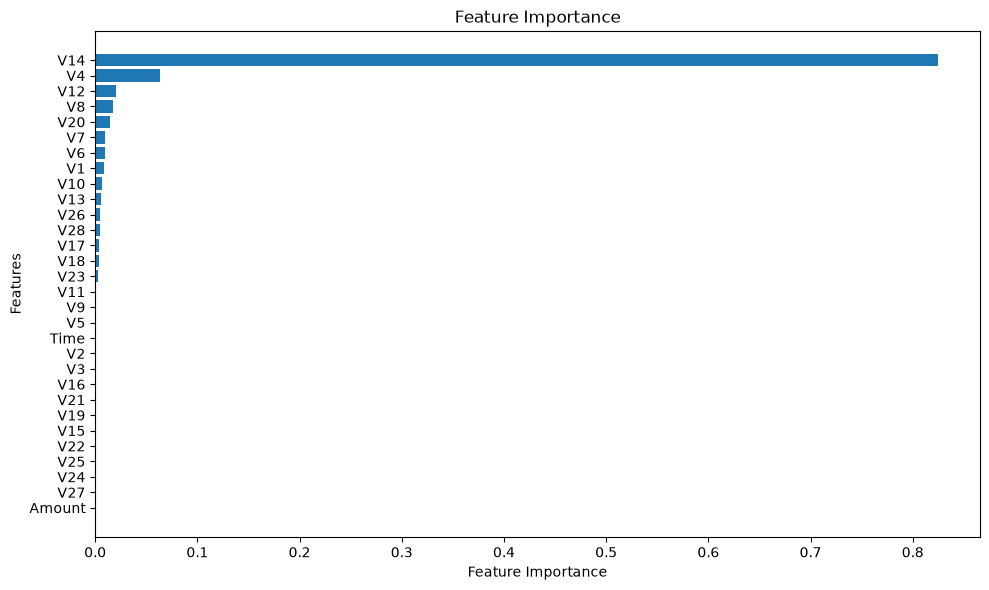

In [16]:
# Plot Feature Importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
# Select Important Features

importance_threshold = feature_importance["Importance"].median()

selected_features = feature_importance[
    feature_importance["Importance"] >= importance_threshold
]["Feature"].tolist()

print("\nSelected Features:")
print(selected_features)

print("\nOriginal Features:", X.shape[1])
print("Selected Features:", len(selected_features))


Selected Features:
['V14', 'V4', 'V12', 'V8', 'V20', 'V7', 'V6', 'V1', 'V10', 'V13', 'V26', 'V28', 'V17', 'V18', 'V23']

Original Features: 30
Selected Features: 15


In [18]:
# Create New Dataset

X_selected = X[selected_features]

In [19]:
# Split Selected Features

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
# Decision Tree with Selected Features

dt_selected = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_leaf=5,
    class_weight="balanced"
)

dt_selected.fit(
    X_train_selected,
    y_train_selected
)

y_pred_selected = dt_selected.predict(
    X_test_selected
)

In [21]:
# Evaluate Selected Features Model

accuracy_selected = accuracy_score(
    y_test_selected,
    y_pred_selected
)

precision_selected = precision_score(
    y_test_selected,
    y_pred_selected,
    average="weighted",
    zero_division=0
)

recall_selected = recall_score(
    y_test_selected,
    y_pred_selected,
    average="weighted",
    zero_division=0
)

f1_selected = f1_score(
    y_test_selected,
    y_pred_selected,
    average="weighted",
    zero_division=0
)

print("\nBalanced Tree with Feature Selection:")
print("Accuracy :", accuracy_selected)
print("Precision:", precision_selected)
print("Recall   :", recall_selected)
print("F1 Score :", f1_selected)

print("\nClassification Report:")
print(
    classification_report(
        y_test_selected,
        y_pred_selected,
        zero_division=0
    )
)


Balanced Tree with Feature Selection:
Accuracy : 0.9694357641936729
Precision: 0.9981438486459793
Recall   : 0.9694357641936729
F1 Score : 0.9829178667501358

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.05      0.88      0.09        98

    accuracy                           0.97     56962
   macro avg       0.52      0.92      0.54     56962
weighted avg       1.00      0.97      0.98     56962



In [22]:
# Compare Models

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Balanced Decision Tree",
        "Balanced Tree with Feature Selection"
    ],
    "Accuracy": [
        accuracy,
        accuracy_balanced,
        accuracy_selected
    ],
    "Precision": [
        precision,
        precision_balanced,
        precision_selected
    ],
    "Recall": [
        recall,
        recall_balanced,
        recall_selected
    ],
    "F1 Score": [
        f1,
        f1_balanced,
        f1_selected
    ]
})

print("\nModel Comparison:")
print(comparison)



Model Comparison:
                                  Model  Accuracy  Precision    Recall  \
0                         Decision Tree  0.999438   0.999414  0.999438   
1                Balanced Decision Tree  0.969436   0.998144  0.969436   
2  Balanced Tree with Feature Selection  0.969436   0.998144  0.969436   

   F1 Score  
0  0.999420  
1  0.982918  
2  0.982918  


In [23]:
# Conclusion

print("\nConclusion:")

print(
    "Decision trees can overfit when there are many features "
    "or when the tree is too complex."
)

print(
    "Class imbalance can make the model favor the majority class."
)

print(
    "Using class_weight='balanced' helps give more importance "
    "to the minority class."
)

print(
    "Feature selection helps remove less important features "
    "and can improve model generalisation."
)


Conclusion:
Decision trees can overfit when there are many features or when the tree is too complex.
Class imbalance can make the model favor the majority class.
Using class_weight='balanced' helps give more importance to the minority class.
Feature selection helps remove less important features and can improve model generalisation.
